[ 0.54545455  0.54545455  0.54545455 ... 36.         48.
 36.        ]


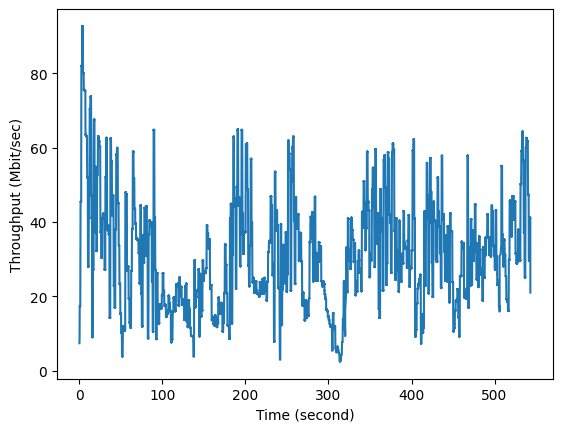

In [10]:
import numpy as np
import matplotlib.pyplot as plt


PACKET_SIZE = 1500.0  # bytes
BITS_IN_BYTE = 8.0
MBITS_IN_BITS = 1000000.0
MILLISECONDS_IN_SECONDS = 1000.0
N = 100
LINK_FILE = '../mahimahi_traces/test_traces/report_bus_0009.log'


time_all = []
packet_sent_all = []
last_time_stamp = 0
packet_sent = 0
with open(LINK_FILE, 'rb') as f:
	for line in f:
		time_stamp = int(line.split()[0])
		if time_stamp == last_time_stamp:
			packet_sent += 1
			continue
		else:
			time_all.append(last_time_stamp)
			packet_sent_all.append(packet_sent)
			packet_sent = 1
			last_time_stamp = time_stamp

time_window = np.array(time_all[1:]) - np.array(time_all[:-1])
throuput_all = PACKET_SIZE * \
			   BITS_IN_BYTE * \
			   np.array(packet_sent_all[1:]) / \
			   time_window * \
			   MILLISECONDS_IN_SECONDS / \
			   MBITS_IN_BITS

print(throuput_all)
plt.plot(np.array(time_all[1:]) / MILLISECONDS_IN_SECONDS, 
		 np.convolve(throuput_all, np.ones(N,)/N, mode='same'))
plt.xlabel('Time (second)')
plt.ylabel('Throughput (Mbit/sec)')
plt.show()

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

TRACE_FOLDER = '../scaled_traces'
OUTPUT_FOLDER = './trace_graphsv2/'

PACKET_SIZE = 1500.0  # bytes
BITS_IN_BYTE = 8.0
MBITS_IN_BITS = 1_000_000.0
MILLISECONDS_IN_SECONDS = 1000.0

# Moving average smoothing window
SMOOTH_WINDOW = 100

# ============================================================
# CREATE OUTPUT FOLDER
# ============================================================

if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# ============================================================
# PROCESS ALL TRACE FILES
# ============================================================

files = sorted(os.listdir(TRACE_FOLDER))

for trace_file in files:

    if not trace_file.endswith('.log'):
        continue

    trace_path = os.path.join(TRACE_FOLDER, trace_file)

    print(f'📊 Processing: {trace_file}')

    time_all = []
    packet_sent_all = []

    last_time_stamp = 0
    packet_sent = 0

    try:

        with open(trace_path, 'r') as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                time_stamp = int(line.split()[0])

                if time_stamp == last_time_stamp:
                    packet_sent += 1

                else:
                    time_all.append(last_time_stamp)
                    packet_sent_all.append(packet_sent)

                    packet_sent = 1
                    last_time_stamp = time_stamp

        # ====================================================
        # VALIDATION
        # ====================================================

        if len(time_all) < 2:
            print(f'⚠️ Skip (trace terlalu pendek): {trace_file}')
            continue

        # ====================================================
        # COMPUTE THROUGHPUT
        # ====================================================

        time_window = (
            np.array(time_all[1:]) -
            np.array(time_all[:-1])
        )

        throughput_all = (
            PACKET_SIZE *
            BITS_IN_BYTE *
            np.array(packet_sent_all[1:]) /
            time_window *
            MILLISECONDS_IN_SECONDS /
            MBITS_IN_BITS
        )

        # ====================================================
        # SMOOTHING
        # ====================================================

        smooth_throughput = np.convolve(
            throughput_all,
            np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW,
            mode='same'
        )

        # ====================================================
        # TIME AXIS
        # ====================================================

        time_sec = (
            np.array(time_all[1:]) /
            MILLISECONDS_IN_SECONDS
        )

        # ====================================================
        # CREATE GRAPH
        # ====================================================

        plt.figure(figsize=(14, 5))

        plt.plot(time_sec, smooth_throughput)

        plt.title(trace_file)
        plt.xlabel('Time (seconds)')
        plt.ylabel('Throughput (Mbps)')

        plt.grid(True)

        # ====================================================
        # SAVE IMAGE
        # ====================================================

        output_image = os.path.join(
            OUTPUT_FOLDER,
            trace_file.replace('.log', '.png')
        )

        plt.savefig(output_image, dpi=150, bbox_inches='tight')

        plt.close()

        print(f'✅ Saved: {output_image}')

    except Exception as e:

        print(f'❌ Error processing {trace_file}: {e}')

print('\n🎉 Semua graph selesai dibuat.')

📊 Processing: report_bicycle_0001.log
✅ Saved: ./trace_graphsv2/report_bicycle_0001.png
📊 Processing: report_bicycle_0002.log
✅ Saved: ./trace_graphsv2/report_bicycle_0002.png
📊 Processing: report_bus_0001.log
✅ Saved: ./trace_graphsv2/report_bus_0001.png
📊 Processing: report_bus_0002.log
✅ Saved: ./trace_graphsv2/report_bus_0002.png
📊 Processing: report_bus_0003.log
✅ Saved: ./trace_graphsv2/report_bus_0003.png
📊 Processing: report_bus_0004.log
✅ Saved: ./trace_graphsv2/report_bus_0004.png
📊 Processing: report_bus_0005.log
✅ Saved: ./trace_graphsv2/report_bus_0005.png
📊 Processing: report_bus_0006.log
✅ Saved: ./trace_graphsv2/report_bus_0006.png
📊 Processing: report_bus_0007.log
✅ Saved: ./trace_graphsv2/report_bus_0007.png
📊 Processing: report_bus_0008.log
✅ Saved: ./trace_graphsv2/report_bus_0008.png
📊 Processing: report_bus_0009.log
✅ Saved: ./trace_graphsv2/report_bus_0009.png
📊 Processing: report_bus_0010.log
✅ Saved: ./trace_graphsv2/report_bus_0010.png
📊 Processing: report_bus

In [1]:
print("ok")

ok
